## Import Library

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from tensorflow.data import Dataset

## Load Dataset

In [ ]:
DATASET_PATH = "Dataset/"
images = []

for filename in os.listdir(DATASET_PATH):
    img = load_img(f"{DATASET_PATH}/{filename}", target_size=(64, 64))
    img = img_to_array(img)
    images.append(img)

## Data Preprocessing & Split

In [ ]:
# bikin jadi float + normalisasi
images = np.asarray(images).astype(np.float32) / 255.0 

# split
total = len(images)
split = int(total * 0.8)

x_train = images[:split] # ambil semua kecuali 10 akhir
x_test = images[split:] # ambil semua kecuali 10 depan

IMAGE_ORIGINAL_SHAPE = x_train.shape[1:] # simpen bentuk, contoh (64, 64, 3)
IMAGE_SIZE = IMAGE_ORIGINAL_SHAPE[0] * IMAGE_ORIGINAL_SHAPE[1] * IMAGE_ORIGINAL_SHAPE[2]

LATENT_DIM = 32
HIDDEN_DIM_1 = 512
HIDDEN_DIM_2 = 256
MAX_EPOCHS = 20 # soal minta 50
LEARNING_RATE = 0.0001
BATCH_SIZE = min(8, max(1, x_train.shape[0])) 
#^^kalo data banyak, dia ambil max (8), kalo dikit ambil min (1)
# BATCH_SIZE = 8 --> biasa pake ini (soalny data banyak)

print(f"IMAGE ORIGINAL SHAPE: {IMAGE_ORIGINAL_SHAPE}")
print(f"IMAGE SIZE: {IMAGE_SIZE}")
print(f"TRAINING SIZE: {len(x_train)}")
print(f"TEST SIZE: {len(x_test)}")

IMAGE ORIGINAL SHAPE: (64, 64, 3)
IMAGE SIZE: 12288
TRAINING SIZE: 240
TEST SIZE: 60


In [ ]:
# shuffling & training
dataset = Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BATCH_SIZE*5).batch(BATCH_SIZE)

## Model Architecture (fully connected)

In [ ]:
# figure 1
class VAE(Model):
    def __init__(self, hidden_dim1, hidden_dim2, latent_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)

        # encoder
        self.fc1 = Dense(hidden_dim1, activation='relu')
        self.enc1 = BatchNormalization()
        self.fc2 = Dropout(0.2)

        self.fc3 = Dense(hidden_dim2, activation='relu')
        self.enc2 = BatchNormalization()
        self.fc4 = Dropout(0.2)

        self.fc5 = Dense(latent_dim) # mu
        self.fc6 = Dense(latent_dim) # log_var

        # decoder 
        self.fc7 = Dense(hidden_dim2)
        self.dec1 = BatchNormalization()
        self.fc8 = Dropout(0.2)

        self.fc9 = Dense(hidden_dim1)
        self.dec2 = BatchNormalization()
        self.fc10 = Dense(IMAGE_SIZE)

        self.dec3 = BatchNormalization()

    def encode(self, x):
        x = self.fc1(x)
        x = self.enc1(x)
        x = self.fc2(x)

        x = self.fc3(x)
        x = self.enc2(x)
        x = self.fc4(x)
        
        mu = self.fc5(x)
        log_var = self.fc6(x)

        return mu, log_var # mean & log var

    def reparameterize(self, mu, log_var): # hafal mati
        std = tf.exp(log_var * 0.5)
        eps = tf.random.normal(std.shape)
        return mu + std * eps
        
    def decode_logits(self, z): 
        z = self.fc7(z)
        z = self.dec1(z)
        z = self.fc8(z)

        z = self.fc9(z)
        z = self.dec2(z)
        z = self.fc10(z)

        z = self.dec3(z)
        return z

    def decode(self, z):
        return tf.nn.sigmoid(self.decode_logits(z))

    def call(self, inputs):
        mu, log_var = self.encode(inputs)
        z = self.reparameterize(mu, log_var)
        x_recon_logits = self.decode_logits(z)
        return x_recon_logits, mu, log_var

## Assemble & Build Model

In [ ]:
model = VAE(HIDDEN_DIM_1, HIDDEN_DIM_2, LATENT_DIM)
model(tf.zeros((BATCH_SIZE, IMAGE_SIZE)))

optimizer = Adam(LEARNING_RATE)

In [ ]:
model.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (8, 512)               │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (8, 512)               │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (8, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (8, 256)               │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (8, 32)                │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (8, 32)                │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (8, 256)               │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (8, 256)               │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (8, 512)               │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (8, 512)               │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (8, 12288)             │     6,303,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (8, 12288)             │        49,152 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,816 (49.36 MB)

 Trainable params: 12,911,168 (49.25 MB)

 Non-trainable params: 27,648 (108.00 KB)

## Train Model

In [ ]:
loss_history = []
kl_div_history = []

for epoch in range(MAX_EPOCHS):
    for x in dataset:
        x = tf.reshape(x, [-1, IMAGE_SIZE])

        with tf.GradientTape() as tape:
            x_recon_logits, mu, log_var = model(x)

            recon_loss = tf.nn.sigmoid_cross_entropy_with_logits(
                labels = x, logits = x_recon_logits
            )

            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(recon_loss, axis=1))

            kl_div = -0.5 * tf.reduce_sum(
              1 + log_var - tf.square(mu) - tf.exp(log_var), axis = 1
            )

            kl_div = tf.reduce_mean(kl_div)

            loss = reconstruction_loss + kl_div

        gradients = tape.gradient(loss, model.trainable_variables)
        gradients = [tf.clip_by_norm(g, 15) for g in gradients]

        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    print(f"Epch [{epoch+1} / {MAX_EPOCHS}] Reconstruction Loss {reconstruction_loss:.4f} KL_DV: {kl_div:.4f}")

    # save loss history
    loss_history.append(reconstruction_loss)
    kl_div_history.append(kl_div)

Epch [1 / 10] Reconstruction Loss 6695.3770 KL_DV: 130.3430
Epch [2 / 10] Reconstruction Loss 6872.5151 KL_DV: 52.6420
Epch [3 / 10] Reconstruction Loss 6843.7383 KL_DV: 30.4064
Epch [4 / 10] Reconstruction Loss 6681.4517 KL_DV: 28.2135
Epch [5 / 10] Reconstruction Loss 6719.5205 KL_DV: 38.5803
Epch [6 / 10] Reconstruction Loss 6975.7461 KL_DV: 28.7571
Epch [7 / 10] Reconstruction Loss 6560.8003 KL_DV: 47.4043
Epch [8 / 10] Reconstruction Loss 6541.8408 KL_DV: 32.1422
Epch [9 / 10] Reconstruction Loss 6634.6270 KL_DV: 36.2284
Epch [10 / 10] Reconstruction Loss 6569.4048 KL_DV: 34.3710


## Show Output

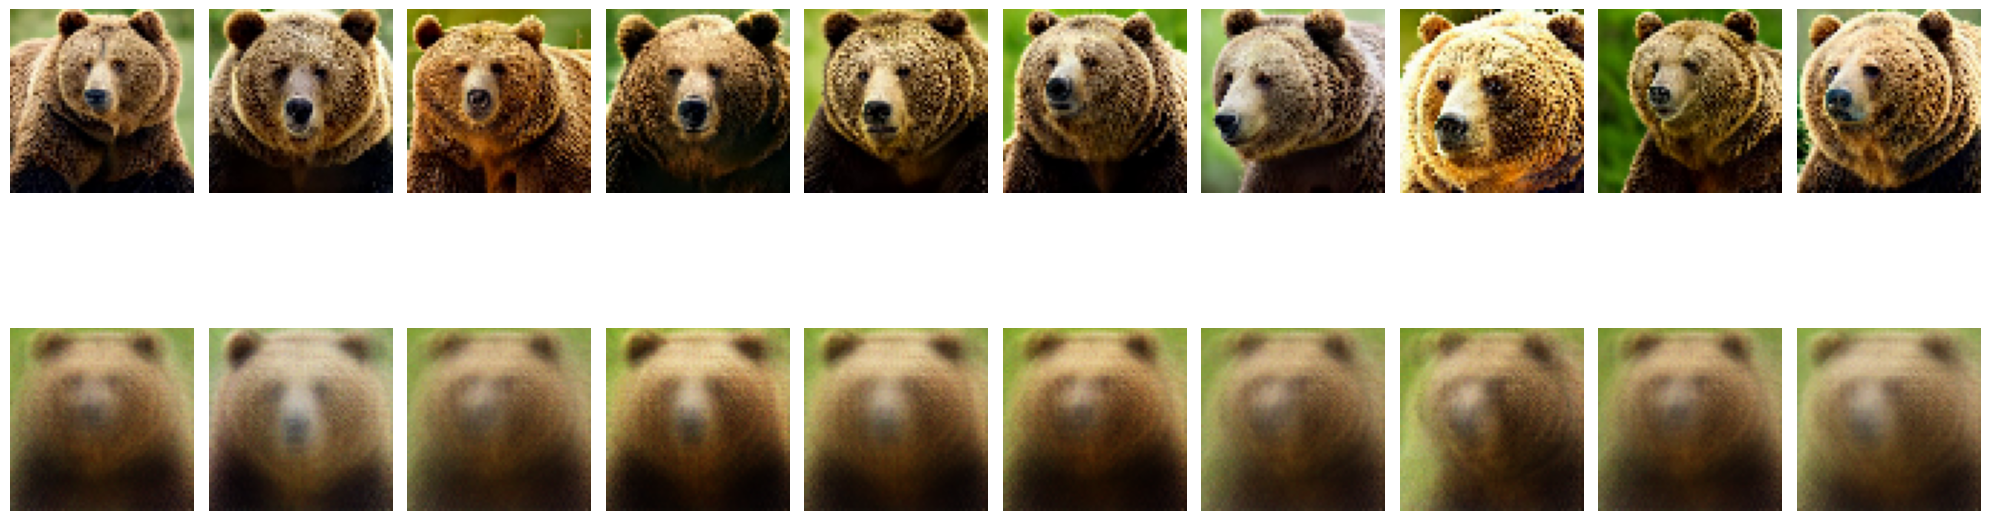

In [ ]:
# mengambil mean dan log variasi dari test data
mu, log_var = model.encode(x_test.reshape(-1, IMAGE_SIZE))
z = model.reparameterize(mu, log_var)

# decode hasil sampilng untuk hasilin gambar rekonstruksi
out = model.decode(z)
out = tf.reshape(
    out, 
    [-1, IMAGE_ORIGINAL_SHAPE[0], IMAGE_ORIGINAL_SHAPE[1], IMAGE_ORIGINAL_SHAPE[2]]
).numpy()*255

out = out.astype(np.uint8) # convert ke uint8, biar dalam bentuk image

num = 10

plt.figure(figsize=(20, 8))
for i in range(num):
    ax = plt.subplot(2, num, i+1)
    plt.imshow(x_test[i].reshape(IMAGE_ORIGINAL_SHAPE), cmap='gray')
    ax.axis('off')

for i in range(num):
    ax = plt.subplot(2, num, num+i+1)
    plt.imshow(out[i].reshape(IMAGE_ORIGINAL_SHAPE), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()
